# Fraud Detection: Exploratory Data Analysis I
## Number of Transactions per Class and Type


In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [127]:
data = pd.read_csv('/content/CreditCardFraud_Dataset.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   TransactionID    10000 non-null  object
 1   Time             10000 non-null  int64 
 2   Amount           10000 non-null  int64 
 3   MerchantID       10000 non-null  object
 4   TransactionType  10000 non-null  object
 5   Class            10000 non-null  object
dtypes: int64(2), object(4)
memory usage: 468.9+ KB


# Transaction Class (Target Variable)

The target variable is the transaction class: a boolean variable that classifies transactions as either normal or fraudulent. From the 10,000 transactions in the dataset, 9,767 of them are normal, while 233 are fraudulent. That is, 2.33% of the transactions are fraudulent, while the other 97.67% are normal.

In [128]:
# total number of transactions by class
class_data = data.pivot_table(
    columns="Class",
    values="TransactionID",
    aggfunc="count"
)

# total number of transactions and percentages
class_data["Total"] = class_data['Fraudulent'] + class_data['Normal']
class_data["Fraudulent %"] = class_data['Fraudulent'] / class_data['Total'] * 100
class_data["Normal %"] = class_data['Normal'] / class_data['Total'] * 100

print(class_data)

Class          Fraudulent  Normal  Total  Fraudulent %  Normal %
TransactionID         233    9767  10000          2.33     97.67


<Axes: title={'center': 'Transaction Class'}>

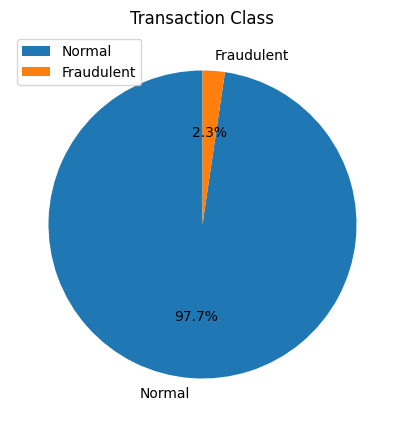

In [129]:
# pie chart: transaction class
data["Class"].value_counts().plot(
    kind="pie",
    title="Transaction Class",
    legend=True,
    figsize=(5, 5),
    startangle=90,
    ylabel="",
    autopct="%1.1f%%"
    )

# Transaction Type

There are three types of transaction: online, mobile, and in-store. From the 10,000 transactions, 3,418 were executed online, 3,393 via mobil, and 3,189 in-store. That is, 34.2% of the transactions were executed online, 33.9% via mobile, and 31.9% were executed in-store.


In [130]:
# number of transactions per type
type_data = data.pivot_table(
    columns="TransactionType",
    values="TransactionID",
    aggfunc="count"
)

# total number of transactions and percentages
type_data["Total"] = type_data['Online'] + type_data['Mobile'] + type_data['In-Store']
type_data["Online %"] = type_data['Online'] / type_data['Total'] * 100
type_data["Mobile %"] = type_data['Mobile'] / type_data['Total'] * 100
type_data["In-Store %"] = type_data['In-Store'] / type_data['Total'] * 100

print(type_data)

TransactionType  In-Store  Mobile  Online  Total  Online %  Mobile %  \
TransactionID        3189    3393    3418  10000     34.18     33.93   

TransactionType  In-Store %  
TransactionID         31.89  


<Axes: title={'center': 'TransactionType'}>

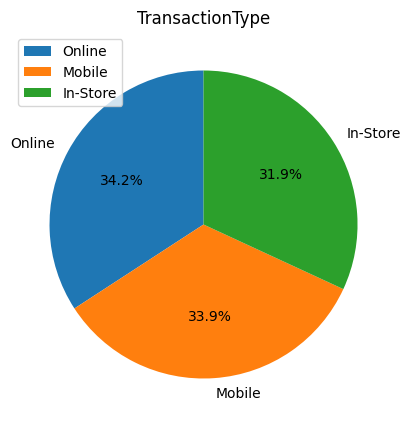

In [135]:
# pie chart: transaction type
data["TransactionType"].value_counts().plot(
    kind="pie",
    title="TransactionType",
    legend=True,
    figsize=(5, 5),
    startangle=90,
    ylabel="",
    autopct="%1.1f%%"
    )

# Fraudulent Transactions per Transaction Type

No in-store transaction was fraudulent. However, 123 online transactions and 110 mobile transactions were fraudulent. In other words, 3.6% of the online transactions were fraudulent, while 3.2% of the mobile transactions were fraudulent.

In [136]:
# number of fraudulent transactions per type
type_class = data.pivot_table(
    index="TransactionType",
    columns="Class",
    values="TransactionID",
    aggfunc="count",
    fill_value=0
)

# fraud rate
type_class["Total"] = type_class["Fraudulent"] + type_class["Normal"]
type_class["Fraud Rate"] = type_class["Fraudulent"] / type_class["Total"] * 100
type_class["Fraud Rate"] = round(type_class["Fraud Rate"], 2)

print(type_class)

Class            Fraudulent  Normal  Total  Fraud Rate
TransactionType                                       
In-Store                  0    3189   3189        0.00
Mobile                  110    3283   3393        3.24
Online                  123    3295   3418        3.60


<Axes: title={'center': 'Online Transactions'}>

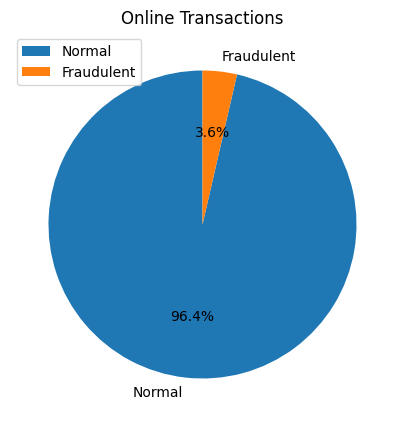

In [137]:
# pie chart: online transactions
data[data["TransactionType"] == "Online"]["Class"].value_counts().plot(
    kind="pie",
    title="Online Transactions",
    legend=True,
    figsize=(5, 5),
    startangle=90,
    ylabel="",
    autopct="%1.1f%%"
    )

<Axes: title={'center': 'Mobile Transactions'}>

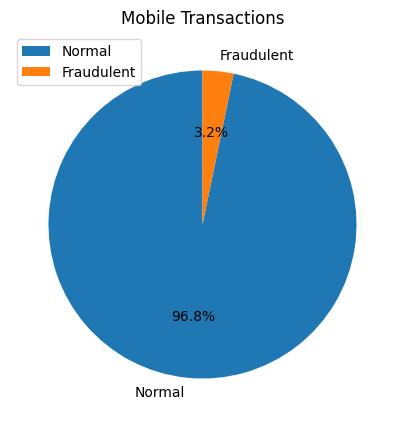

In [138]:
# pie chart: mobile transactions
data[data["TransactionType"] == "Mobile"]["Class"].value_counts().plot(
    kind="pie",
    title="Mobile Transactions",
    legend=True,
    figsize=(5, 5),
    startangle=90,
    ylabel="",
    autopct="%1.1f%%"
    )